# Grocery Dataset Product Image
https://www.kaggle.com/amoghmisra27/grocery

# Get a list of all files and subdirectories

In [1]:
import os

path = '../input/grocery/GroceryStoreDataset-master/dataset/train/'

file_list = []

for root, dirs, files in os.walk(path):
#     print('Root : ', root)
#     print('Dirs : ', dirs)
#     print('Files : ', files)
    for file in files:
        file_list.append(os.path.join(root, file))

        
# print(file_list)
print(len(file_list))
        


2640


In [2]:
path = '../input/grocery/GroceryStoreDataset-master/dataset/train/Fruit/Apple'

folder_list = []

for root, dirs, files in os.walk(path):
#     print('Root : ', root)
#     print('Dirs : ', dirs)
#     print('Files : ', files)

    if len(dirs) > 0:
        folder_list.append(dirs)

        
print(folder_list)
print(len(folder_list))

[['Golden-Delicious', 'Granny-Smith', 'Royal-Gala', 'Red-Delicious', 'Pink-Lady']]
1


# Import Library

In [3]:
import numpy as np  
import pandas as pd  

import matplotlib.pyplot as plt
%matplotlib inline

import cv2
import glob # to find files recursively

import keras 
import tensorflow as tf

from tensorflow.keras.preprocessing import image_dataset_from_directory


In [4]:
# fruits = ['Pineapple' , 'Cocos']
# for x, y in enumerate(fruits):
#     print("X : ", x)
#     print("Y : ", y)

In [5]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale = 1./255., # Rescaling
    rotation_range = 40, # for augmentation
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True
)

In [6]:
train_path = '../input/grocery/GroceryStoreDataset-master/dataset/train/'
image_size = (224, 224)
batch_size = 32

train_generator = train_datagen.flow_from_directory(
    train_path,
    batch_size = batch_size,
    class_mode = 'categorical',
    target_size = image_size
)

# https://keras.io/api/preprocessing/image/#flowfromdirectory-method

Found 2640 images belonging to 3 classes.


In [7]:
train_generator

In [8]:
train_generator[1]

(array([[[[7.37163782e-01, 4.64657605e-01, 1.28128737e-01],
          [7.56044388e-01, 4.85782146e-01, 1.21212356e-01],
          [7.81389832e-01, 5.13686121e-01, 1.20275095e-01],
          ...,
          [6.94344699e-01, 4.66934174e-01, 2.27678001e-01],
          [7.45673001e-01, 4.77759033e-01, 2.65491754e-01],
          [7.90928006e-01, 4.62745488e-01, 2.73737639e-01]],
 
         [[7.95485735e-01, 5.28516471e-01, 1.25880197e-01],
          [8.04521084e-01, 5.39562762e-01, 1.18344247e-01],
          [8.09754968e-01, 5.38863122e-01, 1.15588032e-01],
          ...,
          [6.98095083e-01, 4.62631702e-01, 2.33533531e-01],
          [7.57809222e-01, 4.66111958e-01, 2.64655232e-01],
          [7.87843227e-01, 4.58623618e-01, 2.58340865e-01]],
 
         [[8.33988905e-01, 5.72691739e-01, 1.09185673e-01],
          [8.36228132e-01, 5.81569731e-01, 8.34391490e-02],
          [8.35409403e-01, 5.71197987e-01, 1.11987881e-01],
          ...,
          [6.97022855e-01, 4.57976252e-01, 2.4186

In [9]:
train_generator[0][0][0]

array([[[0.09600069, 0.10311824, 0.04531398],
        [0.07718747, 0.08503061, 0.0333808 ],
        [0.06458487, 0.07573631, 0.03798918],
        ...,
        [0.06903967, 0.0615586 , 0.05252896],
        [0.06424984, 0.06032828, 0.05248514],
        [0.05827351, 0.05435194, 0.0465088 ]],

       [[0.11206788, 0.11717704, 0.05133918],
        [0.08522107, 0.0930642 , 0.03940599],
        [0.07061007, 0.07975312, 0.03397238],
        ...,
        [0.05822277, 0.0543012 , 0.04645806],
        [0.05401679, 0.05009522, 0.04225208],
        [0.05202467, 0.04810311, 0.04025996]],

       [[0.12074783, 0.1254902 , 0.05243955],
        [0.09631325, 0.10339174, 0.04543119],
        [0.07734375, 0.08518688, 0.033498  ],
        ...,
        [0.05200776, 0.04808619, 0.04024306],
        [0.05194514, 0.04802357, 0.04018044],
        [0.05393725, 0.05001568, 0.04217255]],

       ...,

       [[0.46953028, 0.40152204, 0.34042168],
        [0.47295174, 0.44014362, 0.36409318],
        [0.52275455, 0

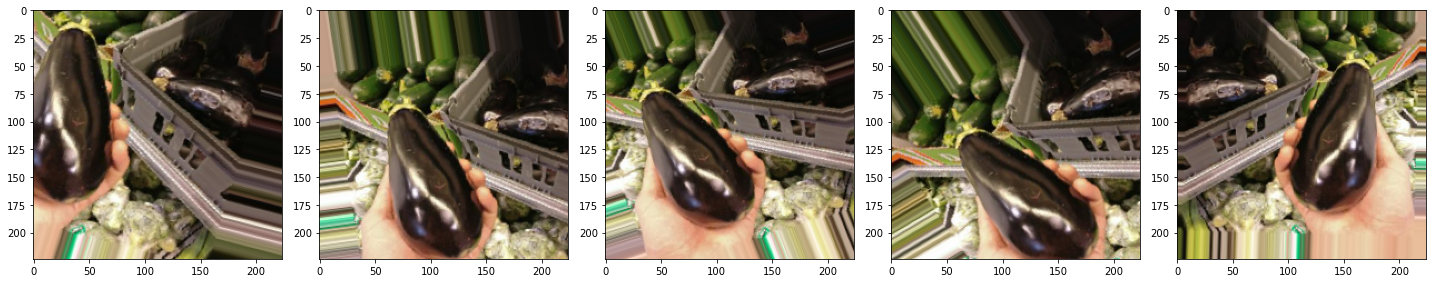

In [10]:
def plotImages(images_arr):
    fig, axes = plt.subplots(1, 5, figsize=(20,20))
    axes = axes.flatten()
    for img, ax in zip( images_arr, axes):
        ax.imshow(img)
    plt.tight_layout()
    plt.show()
    
    
augmented_images = [train_generator[0][0][0] for i in range(10)]
plotImages(augmented_images)

In [11]:
labels = (train_generator.class_indices)
labels

{'Fruit': 0, 'Packages': 1, 'Vegetables': 2}

In [12]:
labels = dict((v,k) for k,v in labels.items()) 
labels

{0: 'Fruit', 1: 'Packages', 2: 'Vegetables'}

In [13]:
no_classes = len(labels)

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D
from tensorflow.keras.losses import sparse_categorical_crossentropy
from tensorflow.keras.optimizers import Adam

In [15]:
# Create the model
model = Sequential()
model.add(Conv2D(16, kernel_size=(5, 5), activation='relu', input_shape=(224, 224, 3)))
model.add(Conv2D(32, kernel_size=(5, 5), activation='relu'))
model.add(Conv2D(64, kernel_size=(5, 5), activation='relu'))
model.add(Conv2D(128, kernel_size=(5, 5), activation='relu'))
model.add(Flatten())
model.add(Dense(16, activation='relu'))
model.add(Dense(no_classes, activation='softmax'))

# Display a model summary
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 220, 220, 16)      1216      
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 216, 216, 32)      12832     
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 212, 212, 64)      51264     
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 208, 208, 128)     204928    
_________________________________________________________________
flatten (Flatten)            (None, 5537792)           0         
_________________________________________________________________
dense (Dense)                (None, 16)                88604688  
_________________________________________________________________
dense_1 (Dense)              (None, 3)                 5

In [16]:
# Compile the model
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(),
              metrics=['accuracy']
             )

# Start training
model.fit(
        train_generator,
        epochs = 10,
        shuffle = False
)

Epoch 1/10
83/83 [==============================] - 51s 616ms/step - loss: 2.9450 - accuracy: 0.5087
Epoch 2/10
83/83 [==============================] - 49s 591ms/step - loss: 0.9029 - accuracy: 0.6004
Epoch 3/10
83/83 [==============================] - 49s 591ms/step - loss: 0.8350 - accuracy: 0.6466
Epoch 4/10
83/83 [==============================] - 50s 597ms/step - loss: 0.8059 - accuracy: 0.6629
Epoch 5/10
83/83 [==============================] - 49s 596ms/step - loss: 0.8065 - accuracy: 0.6523
Epoch 6/10
83/83 [==============================] - 49s 595ms/step - loss: 0.7798 - accuracy: 0.6523
Epoch 7/10
83/83 [==============================] - 49s 590ms/step - loss: 0.7324 - accuracy: 0.6731
Epoch 8/10
83/83 [==============================] - 49s 588ms/step - loss: 0.7274 - accuracy: 0.6883
Epoch 9/10
83/83 [==============================] - 48s 579ms/step - loss: 0.7130 - accuracy: 0.6754
Epoch 10/10
83/83 [==============================] - 48s 581ms/step - loss: 0.6533 - accura

# Test Dataset

In [19]:
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator()

test_path = '../input/grocery/GroceryStoreDataset-master/dataset/test/'

test_generator = test_datagen.flow_from_directory(
    directory = test_path,
    batch_size = batch_size,
    class_mode = 'categorical',
    target_size = image_size,
    shuffle = False,
    seed = 42
)    

Found 2485 images belonging to 3 classes.


In [20]:
pred = model.predict_generator(
    test_generator,
    verbose=1
)

78/78 [==============================] - 12s 157ms/step


In [21]:
predicted_class_indices=np.argmax(pred,axis=1)

In [22]:
predictions = [labels[k] for k in predicted_class_indices]

In [23]:
predictions

['Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',
 'Fruit',


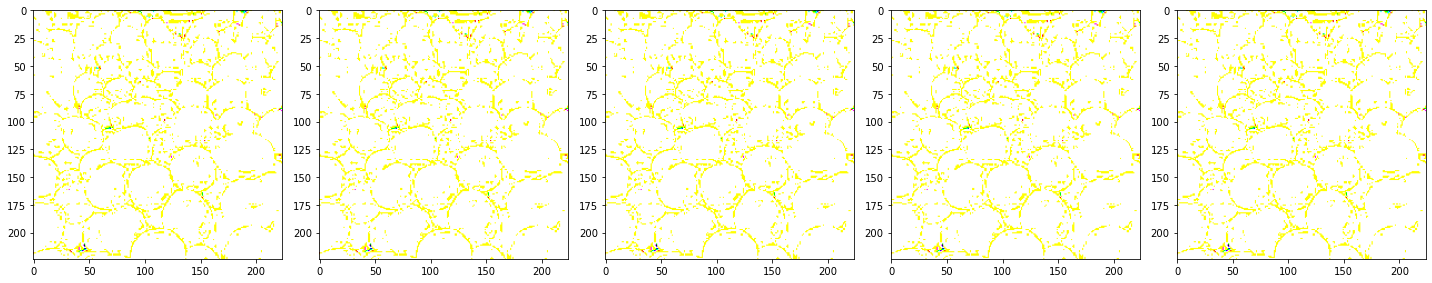

In [24]:
augmented_images = [test_generator[0][0][0] for i in range(10)]
plotImages(augmented_images)

In [25]:
filenames = test_generator.filenames
results = pd.DataFrame({"Filename":filenames,
                      "Predictions":predictions})
results.to_csv("results.csv",index=False)

In [26]:
results.head()

,Filename,Predictions
0,Fruit/Apple/Golden-Delicious/Golden-Delicious_...,Fruit
1,Fruit/Apple/Golden-Delicious/Golden-Delicious_...,Fruit
2,Fruit/Apple/Golden-Delicious/Golden-Delicious_...,Fruit
3,Fruit/Apple/Golden-Delicious/Golden-Delicious_...,Fruit
4,Fruit/Apple/Golden-Delicious/Golden-Delicious_...,Fruit


In [27]:
results.tail()

,Filename,Predictions
2480,Vegetables/Zucchini/Zucchini_025.jpg,Fruit
2481,Vegetables/Zucchini/Zucchini_026.jpg,Fruit
2482,Vegetables/Zucchini/Zucchini_027.jpg,Fruit
2483,Vegetables/Zucchini/Zucchini_028.jpg,Fruit
2484,Vegetables/Zucchini/Zucchini_029.jpg,Fruit
